# 4.4.2 邻近轨迹与预测期限

## 学习目标与先修知识

能量化两个初值（initial condition）的逐代距离，按明确阈值报告有限预测期限，解释增长、饱和和精度合并，并区分三类误差来源。

先修：上一节的 logistic 映射（logistic map）；指数增长、对数及局部扰动近似。 [复习上一节](01-离散映射的不动点与周期.ipynb)。

## 具体问题

如果初始种群比例只测准到有限位数，确定的更新规则能否保证长期逐代预测？用两条邻近初值的轨迹（trajectory），明确“还能预测”是相对哪个误差标准。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
first,second=.2,.200001
r=3.9
print('初始距离',abs(first-second))
print('一步后的距离',abs(r*first*(1-first)-r*second*(1-second)))
print('局部倍率近似',abs(r*(1-2*first))*abs(first-second))

初始距离 1.000000000001e-06
一步后的距离 2.3399960999981317e-06
局部倍率近似 2.34000000000234e-06


## 模型假设

仍为 x[n+1]=r*x[n]*(1−x[n])。两个初值为 0.2 与 0.200001，共同 r=3.9，观察 80 代；距离 d_n=|x_n−y_n|，阈值 ε=0.05，首次 d_n>ε 的下标为本次预测期限。

两条轨迹采用相同的确定性规则，从主动设定的两个邻近初值出发；计算中还会引入浮点舍入误差（round-off error）。

## 数学解释与推导

由 Taylor 一阶近似，δ_(n+1)≈F′(x_n)δ_n。只在两条轨迹仍足够近时，才可把绝对距离近似乘以 |F′|。若一段窗口的典型对数倍率为 λ>0，则粗略地
$$d_n\approx d_0e^{\lambda n},\qquad n_\text{predict}\approx\frac{\log(\varepsilon/d_0)}\lambda.$$
这是用来理解数量级的局部近似；实际距离可先增后减，窗口内的增长率也不恒定，所以最终期限应按约定阈值从实际序列计算。

本例两条轨迹都在 [0,1]，距离最多为 1，不可能永久指数增长。分离大到与状态（state）范围相当后，局部线性关系已经失效；距离饱和不等于之前没有敏感性。若初值相同，轨迹也完全相同，不能指望确定性代码自动分裂。

首次越界必须包括第 0 代。等于阈值不算严格超过；若到最大步数仍未越界，返回 None，意思是“在观察窗口内未发生”，不表示无限预测能力。

还要检查输入（input）表示：两个十进制数经 float 转换可能变成同一个可表示数。这时零距离只说明扰动在输入阶段已丢失。下一节将明确比较不同算术精度。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def logistic_path(r,initial,steps):
    values=[initial]
    for _ in range(steps):values.append(r*values[-1]*(1-values[-1]))
    return values

def separation(r,first,second,threshold,steps):
    a=logistic_path(r,first,steps)
    b=logistic_path(r,second,steps)
    distances=[abs(x-y) for x,y in zip(a,b)]
    crossing=next((i for i,d in enumerate(distances) if d>threshold),None)
    return distances,crossing

## 对照实验

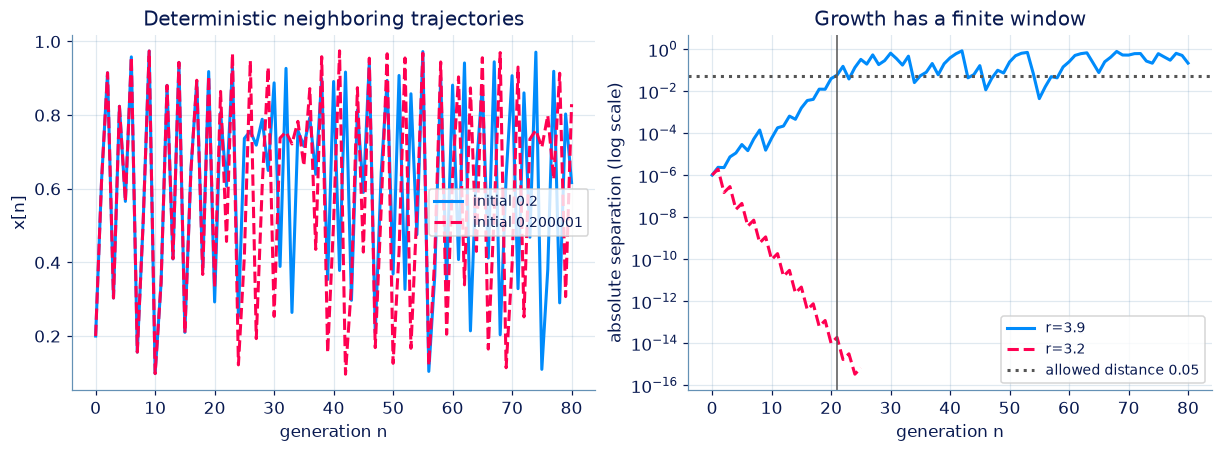

r=3.9 首次越界 21 ；r=3.2 首次越界 None
零距离在对数轴上无法显示，未用任意正数代替。


In [4]:
steps=80;eps=.05
first=logistic_path(3.9,.2,steps);second=logistic_path(3.9,.200001,steps)
distance,horizon=separation(3.9,.2,.200001,eps,steps)
periodic_distance,periodic_horizon=separation(3.2,.2,.200001,eps,steps)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(first,color=BLUE,label='initial 0.2')
axes[0].plot(second,color=PINK,ls='--',label='initial 0.200001')
for d,color,style,label in [(distance,BLUE,'-','r=3.9'),(periodic_distance,PINK,'--','r=3.2')]:
    positive=np.array(d)>0
    axes[1].semilogy(np.arange(steps+1)[positive],np.array(d)[positive],color=color,ls=style,label=label)
axes[1].axhline(eps,color=GRAY,ls=':',label='allowed distance 0.05')
if horizon is not None:axes[1].axvline(horizon,color=GRAY,lw=1)
axes[0].set(xlabel='generation n',ylabel='x[n]',title='Deterministic neighboring trajectories')
axes[1].set(xlabel='generation n',ylabel='absolute separation (log scale)',title='Growth has a finite window')
for ax in axes:ax.legend(fontsize=9)
plt.show()
print('r=3.9 首次越界',horizon,'；r=3.2 首次越界',periodic_horizon)
print('零距离在对数轴上无法显示，未用任意正数代替。')

## 结果解释

左图初期难以分辨，后段分离；右图用对数纵轴展示正的微小差异，零距离点略去。r=3.2 的周期吸引对照提醒我们：非线性参数（parameter）不同，敏感性表现也可能不同。

改变误差阈值、初始差异或观察代数后，期限结论都会改变，报告必须包含这些条件。把预测问题转成一个明确允许误差的问题，比只说“不可预测”更有用。

### 独立核对

边界用可手算的映射恒等式核对。两点关于 1/2 对称时下一代可立即合并，不能假设所有距离都单调增长。

In [5]:
assert separation(4,.25,.75,.5,4)==([.5,0.,0.,0.,0.],None)
assert separation(2,0,1,.5,0)==([1],0)
assert separation(3.9,.2,.2,0,10)==([0.]*11,None)
# One-step difference has an exact algebraic identity before roundoff.
a,b,r=.2,.200001,3.9
actual=abs(r*b*(1-b)-r*a*(1-a))
identity=abs(r*(b-a)*(1-a-b))
assert abs(actual-identity)<1e-15
print('首次下标、严格阈值、合并轨迹和差值恒等式通过。')

首次下标、严格阈值、合并轨迹和差值恒等式通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-04-混沌与可预测范围/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：何时第一次超过误差容许值

在同一个 logistic 映射（logistic map）下推进两个初值（initial condition），逐代计算绝对距离，并找首次严格超过 threshold 的代次。若一直不超过，返回 None。

**函数与代码模板**

```python
def solve(
    r: float,
    first: float,
    second: float,
    threshold: float,
    steps: int,
) -> tuple[list[float], int | None]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `r` | `float` | 共同映射参数（parameter）。 | 1 |
| `first` | `float` | 第一条轨迹（trajectory）的第 0 代。 | 1 |
| `second` | `float` | 第二条轨迹的第 0 代。 | 1 |
| `threshold` | `float` | 允许的绝对距离。 | 1 |
| `steps` | `int` | 更新次数。 | 1 |

**返回值**

按以下顺序返回元组：(distances, first_exceedance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `distances` | `list[float]` | 包含第 0 代的 steps+1 个距离。 | 1 |
| `first_exceedance` | <code>int &#124; None</code> | 第一个严格超阈值下标；包括 0。 | 1 |

**计算规则**

两条轨迹分别按 x←r*x*(1−x) 同步迭代。距离取绝对值；d==threshold 不算超过。 为固定浮点实验，使用 Python float；每次更新按 (r*x)*(1-x) 的括号次序，不改写成 r*(x-x*x)。长轨迹的舍入差异会被放大。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 0≤r≤4；两个初值在 [0,1]；0≤threshold≤1；0≤steps≤120。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| r | 共同映射参数（parameter）。 | 2 | 1 |
| first | 第一条轨迹（trajectory）的第 0 代。 | 0.25 | 1 |
| second | 第二条轨迹的第 0 代。 | 0.5 | 1 |
| threshold | 允许的绝对距离。 | 0.2 | 1 |
| steps | 更新次数。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
r = 2
first = 0.25
second = 0.5
threshold = 0.2
steps = 2

result = solve(r, first, second, threshold, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| distances | 包含第 0 代的 steps+1 个距离。 | [0.25, 0.125, 0.03125] | 1 |
| first_exceedance | 第一个严格超阈值下标；包括 0。 | 0 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.25, 0.125, 0.03125], 0)
```

**样例解释**

第 0 代距离 0.25 已严格超过 0.2，所以首次下标为 0；后续距离缩小也不能改写首次越界。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：何时第一次超过误差容许值](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-prediction-horizon)

### 第 2 题 · 单项选择题：阈值相等算越界吗

距离序列为 [0.01,0.05,0.1,0.08]，要求首次严格超过 0.05。正确下标是？

- **A.** 1
- **B.** 2
- **C.** 3
- **D.** 0

[作答：阈值相等算越界吗](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-strict-threshold)

### 第 3 题 · 多项选择题：距离饱和是否推翻初值敏感性

两条轨迹（trajectory）都在 [0,1]，距离先增大后不再指数上升。哪些成立？

- **A.** 这证明前段增长一定是随机噪声。
- **B.** 应区分小扰动增长窗口与饱和阶段。
- **C.** 距离最多为 1，因此不可能永远指数增长。
- **D.** 远离后局部线性扰动近似可能不再适用。

[作答：距离饱和是否推翻初值敏感性](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-bounded-separation)

### 第 4 题 · 单项选择题：两个输入为何变成同一条轨迹

两个不同十进制初值（initial condition）转成 Python float 后恰好相等。能从二者轨迹（trajectory）距离全零推出什么？

- **A.** 添加随机噪声后原问题自动得到解答。
- **B.** 数学模型（model）不敏感。
- **C.** 只能说明这次计算实际用了同一浮点初值，实验未保留想比较的扰动。
- **D.** 已证明真实预测无限准确。

[作答：两个输入为何变成同一条轨迹](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-precision-merge)

### 第 5 题 · 单项选择题：怎样检查映射计算误差

对原始 logistic 代次映射，哪个精度检查成立？

- **A.** 把一步拆成两次半步更新而不说明新模型（model）。
- **B.** 比较不同算术精度、表达式求值与初值（initial condition）表示；保留原代次定义。
- **C.** 把 r 除以二即可得到更精确的相同轨迹（trajectory）。
- **D.** 使用更多小数位打印即可增加计算精度。

[作答：怎样检查映射计算误差](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-map-not-step)